# El Perceptrón
## (La base de las redes neuronales)

El **Perceptrón** es uno de los modelos más simples para clasificación. Su objetivo es encontrar una **frontera de decisión lineal** que permita separar dos clases.

## Idea central

El modelo calcula primero una combinación lineal de las variables de entrada:

$$
z = w^T x + b
$$

donde:

- $x$ es el vector de características  
- $w$ es el vector de pesos aprendidos  
- $b$ es el intercepto (bias)

Luego decide la clase utilizando una **función escalón**:

$$
\hat{y} =
\begin{cases}
1 & \text{si } z \ge 0 \\
0 & \text{si } z < 0
\end{cases}
$$

## Interpretación geométrica

La ecuación

$$
w^T x + b = 0
$$

define la **frontera de decisión** del modelo.

- En **2D**, esta frontera es una **línea**.
- En **3D**, es un **plano**.
- En dimensiones superiores se denomina **hiperplano**.

Este hiperplano divide el espacio de características en dos regiones, cada una asociada a una clase.

## Cuándo funciona bien

- Cuando los datos son **(casi) linealmente separables**.

## Limitaciones

- Si las clases se traslapan significativamente o la frontera real es curva, el perceptrón puede tener un desempeño limitado.
- No entrega probabilidades, únicamente **decisiones de clasificación**.

## Qué se observará en este notebook

1. Se cargará un dataset sintético.
2. Se entrenará un modelo **Perceptrón** utilizando `scikit-learn`.
3. Se visualizará la **frontera de decisión** y se evaluará el desempeño del modelo.

In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Importando módulo propio
from utils.classification_functions import *

In [3]:
# Leyendo datos

DATA_FILE = "binary_classification_less_separable_3d.csv"

data_path = Path("../data/mocked_data") / DATA_FILE

df = pd.read_csv(data_path)

X = df.drop(columns=["y"])
y = df["y"]

print(f"Dataset loaded: {DATA_FILE}")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded: binary_classification_less_separable_3d.csv
Shape: (20000, 4)


,x1,x2,x3,y
0,0.243460,0.176335,-2.295278,0
1,-0.437769,1.590139,-1.343443,0
2,-1.233956,2.585832,-0.736042,0
3,-0.372753,2.354267,-0.674096,0
4,-1.181945,1.982743,-1.984979,0


In [4]:
X

,x1,x2,x3
0,0.243460,0.176335,-2.295278
1,-0.437769,1.590139,-1.343443
2,-1.233956,2.585832,-0.736042
3,-0.372753,2.354267,-0.674096
4,-1.181945,1.982743,-1.984979
...,...,...,...
19995,0.119163,-1.370490,2.107532
19996,1.050816,-1.651097,0.171419
19997,1.833228,-1.634888,1.463031
19998,-0.071433,-1.852990,2.156631


In [5]:
y

0        0
1        0
2        0
3        0
4        0
        ..
19995    1
19996    1
19997    1
19998    1
19999    1
Name: y, Length: 20000, dtype: int64

## Dividiendo Datos

In [6]:
TEST_SIZE = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (16000, 3)
Test set: (4000, 3)


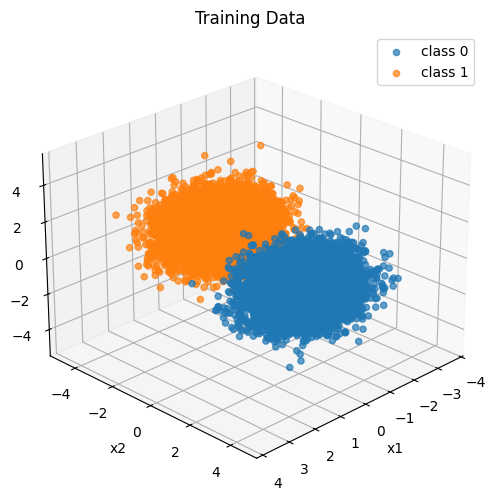

In [7]:
# Plot Training
plot_points(
    X_train.to_numpy(),
    y_train.to_numpy(),
    dims=3,
    title="Training Data"
)


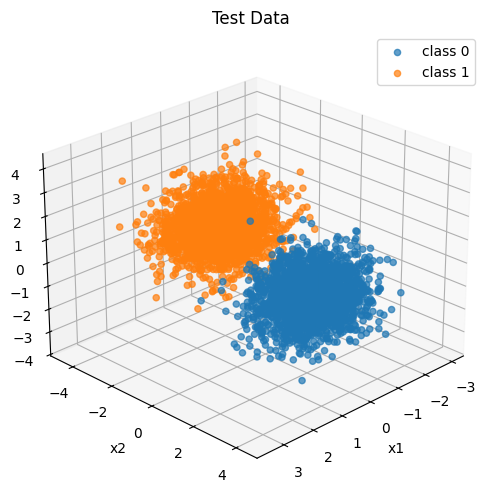

In [8]:
# Plot Test
plot_points(
    X_test.to_numpy(),
    y_test.to_numpy(),
    dims=3,
    title="Test Data"
)

## Entrenando modelo perceptrón

In [9]:
# Hiperparametros

PERCEPTRON_PARAMS = {
    "penalty": None,        # None | "l2" | "l1" | "elasticnet"
    "alpha": 0.0001,
    "l1_ratio": 0.15,
    "fit_intercept": True,
    "max_iter": 5,
    "tol": 1e-3,
    "shuffle": True,
    "eta0": 1.0,
    "random_state": 42
}

In [10]:
# Entrenando Modelo

model = Pipeline([
    #("scaler", StandardScaler()), #Ingeniería de características
    ("perceptron", Perceptron(**PERCEPTRON_PARAMS))
])

model.fit(X_train, y_train) # El modelo no recibe ningún dato de TEST durante el entrenamiento

print("Model trained successfully.")

Model trained successfully.


/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [11]:
# Parametros Entrenados

clf = model.named_steps["perceptron"]

print("Perceptron object:\n")
print(clf)

print("\nLearned attributes:")
print("coef_.shape:", clf.coef_.shape)
print("coef_:", clf.coef_)
print("intercept_.shape:", clf.intercept_.shape)
print("intercept_:", clf.intercept_)
print("n_iter_:", clf.n_iter_)

print("El modelo matemático:")
w = clf.coef_[0]
b = clf.intercept_[0]
print(f"{w[0]:.3f}*x1 + {w[1]:.3f}*x2 + {w[2]:.3f}*x3 + {b:.3f} = 0")


Perceptron object:

Perceptron(max_iter=5, random_state=42)

Learned attributes:
coef_.shape: (1, 3)
coef_: [[ 1.09630855 -3.6040272   2.51239757]]
intercept_.shape: (1,)
intercept_: [-1.]
n_iter_: 5
El modelo matemático:
1.096*x1 + -3.604*x2 + 2.512*x3 + -1.000 = 0


Test Accuracy: 0.9908

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2000
           1       1.00      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



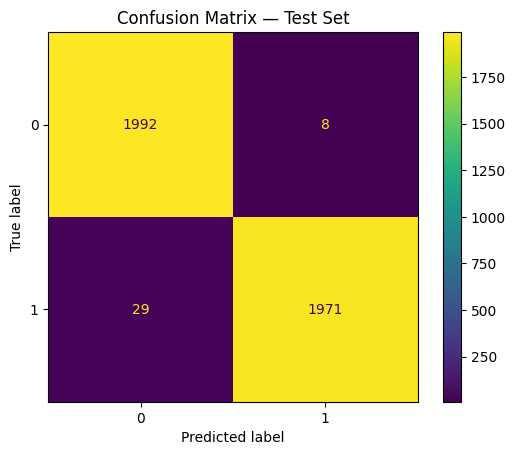

In [12]:
# Evaluando modelo
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix — Test Set")
plt.show()

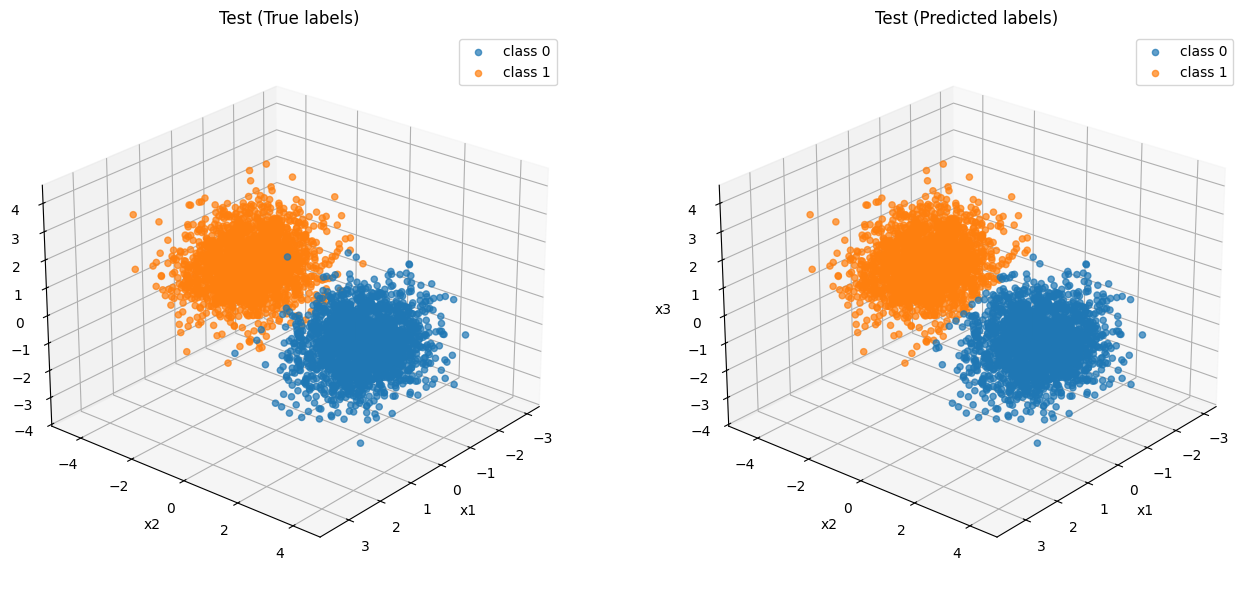

In [16]:
# Visualizando resultados
plot_true_vs_pred(
    X_test,
    y_test,
    y_pred,
    dims=3,          # change to 3 if using 3D data
    elev=25,
    azim=40
)